In [1]:
import sys  
sys.path.insert(1, '/home/phong/bin')
from plotting_header import *
import glob
import ROOT
import time
from IPython.display import display

import numpy as np
from scipy.stats import johnsonsu,norm
from iminuit import Minuit
from iminuit.cost import ExtendedUnbinnedNLL,ExtendedBinnedNLL
import matplotlib.pyplot as plt
from scipy.optimize import minimize,root_scalar
from jacobi import propagate
%matplotlib inline

import matplotlib.font_manager as font_manager
import matplotlib
font = {'family' : 'Liberation Serif',
        'weight' : 'normal',
        'size'   : 28}
matplotlib.rc('font', **font)
matplotlib.use('TkAgg')  # Or 'TkAgg', etc., before any plotting
import numpy as np
from scipy.stats import johnsonsu
from scipy.optimize import minimize_scalar, root_scalar
%matplotlib inline


Welcome to JupyROOT 6.26/14


In [21]:
hpull = ROOT.TH1F("hpull","hpull",100,-10,10)
t12truth = 19.9
with open("simoutput_fit.root.txt","r") as f:
    lines = [l.strip() for l in f.readlines()]
    idx=0
    for i in lines:
        if (idx==2):
            t12 = np.log(2)/float(i.split()[1])
            dt12 = np.log(2)/float(i.split()[1])/float(i.split()[1])*float(i.split()[2])
            hpull.Fill((t12-t12truth)/dt12)
        idx+=1
        if (idx==6):
            idx=0
    print(len(lines))

600


Warning in <TROOT::Append>: Replacing existing TH1: hpull (Potential memory leak).


 FCN=14.4752 FROM MINOS     STATUS=SUCCESSFUL     42 CALLS         182 TOTAL
                     EDM=1.2378e-07    STRATEGY= 1      ERROR MATRIX ACCURATE 
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  Constant     6.72394e+00   8.23513e-01  -3.25199e-02   2.92765e-05
   2  Mean         3.86000e-01   1.18665e-01  -1.87243e-06   5.12870e-05
   3  Sigma        1.18665e+00   8.38996e-02   8.38996e-02   1.89494e-04
                               ERR DEF= 0.5


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1


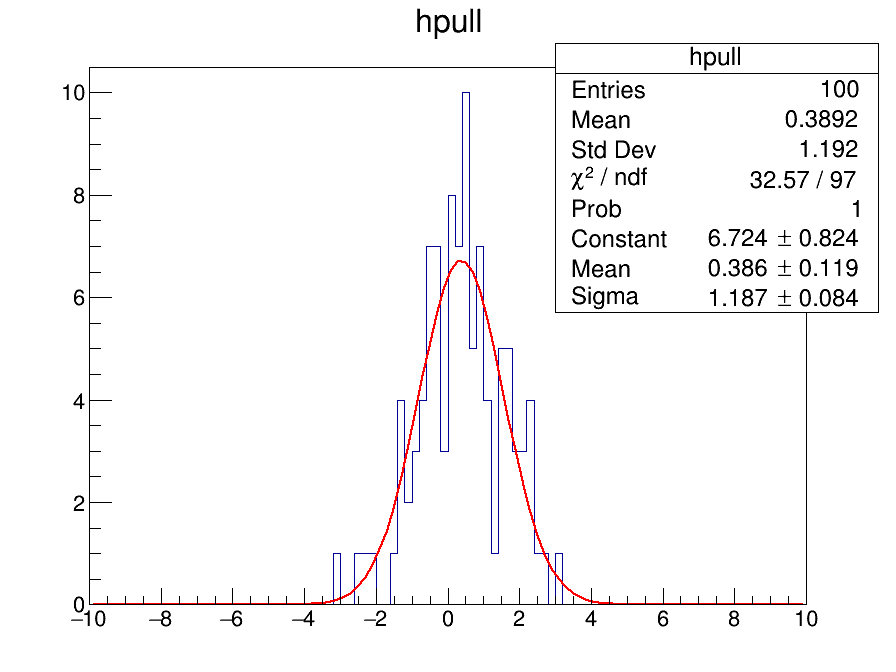

In [23]:
c1 = ROOT.TCanvas("c1","c1",900,700)
c1.cd()
ROOT.gStyle.SetOptFit(111111)
hpull.Fit("gaus","LE+")
hpull.Draw();
c1.Draw()